# Description
Calculation of the number of passes using real breadcrumbs. Finished on May 18th, 2026. It is the first version it can count by boundary cell. The grid is done by rectangles

In [1]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

In [2]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.geometry import LineString, Point
from shapely.affinity import rotate
import numpy as np
import pandas as pd
import geopandas as gpd
import warnings
from inc import *
from shapely.ops import polygonize, unary_union

EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully
EU1_PROD_Conn created successfully
EU2_PROD_Conn created successfully


# Configuration

In [3]:
tol_deg  = 5
street_length = 10
sampling_distance = 10 
dx = 0.5         # Thickness of each vertical bar
d_angles = -10 * np.ones(len(np.arange(0, 181, 10)))  # 10 degree rotation steps from 0 to 360 inclusive

# Query the surveys

In [4]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[700]].copy()
#report_bc = pd.DataFrame({'ReportId': ['FC2E76DB-07A3-C4E4-A3AC-3A205F4F5596']})
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')



l = 0
surveys = segments['SurveyId'].unique()
#survey = segments[segments['SurveyId'] == surveys[l]]
survey = segments
survey['Breadcrumb_wkt'] = survey['Breadcrumb'].apply(wkt.loads)
survey_gdf = gpd.GeoDataFrame(survey, geometry = 'Breadcrumb_wkt', crs = 'EPSG:4326')
utm_crs = survey_gdf.estimate_utm_crs()
survey_gdf = survey_gdf.to_crs(utm_crs)

# Algorithm starts here
## Prepare the surveys

In [5]:
# Compute the union of the survey geometries and simplify the result
#survey_union = survey_gdf.unary_union.simplify(10)  # Adjust tolerance 1.0 as needed
survey_union = survey_gdf.unary_union  # Adjust tolerance 1.0 as needed

# Create a GeoDataFrame from the union
survey_union_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union]},
    crs=survey_gdf.crs
)

# Make an offset of 10 (buffer by 10 units)
survey_union_offset_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union.buffer(street_length/2, cap_style=2)]},
    crs=survey_gdf.crs,
    geometry='geometry'
)

In [6]:
# Get the center as the midpoint of the bounds (average of min/max x/y)
minx, miny, maxx, maxy = survey_union_offset_gdf.total_bounds
center = Point((minx + maxx) / 2, (miny + maxy) / 2)
print("Center of the bounds:", center)

# Shift the survey_union_offset_gdf geometry so that the centroid is at (0, 0)
survey_union_offset_gdf['geometry'] = survey_union_offset_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)

Center of the bounds: POINT (656871.690735 5939083.0724100005)


In [7]:
survey_gdf['geometry'] = survey_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)
survey_gdf.set_geometry('geometry', inplace=True)


/tmp/ipykernel_48723/3853611118.py:4: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


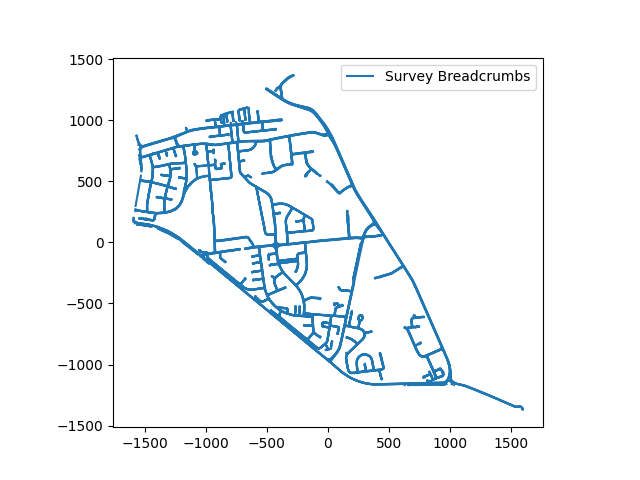

In [8]:
fig,ax = plt.subplots()
survey_gdf.plot(ax=ax, label='Survey Breadcrumbs')
survey_union_offset_gdf.plot(ax=ax, color='red', alpha=0.5, label='Street')
ax.legend()

# Generate the grid

In [9]:
# Assuming 'angle' and 'intersection_gdf' are in scope
def points_and_rotate(bottom, rot_angle):
    # Convert to Point, rotate each, and return as two tuples
    if isinstance(bottom, list) and all(isinstance(pt, tuple) and len(pt) == 2 for pt in bottom):
        rotated = [rotate(Point(pt), angle=rot_angle, origin=(0, 0)) for pt in bottom]
        if len(rotated) == 2:
            return (tuple(rotated[0].coords[0]), tuple(rotated[1].coords[0]))
    return (None, None)



In [10]:
import time
from shapely.geometry import MultiPoint
times = []
def get_max_min_points(df):
   min_x, min_y, max_x, max_y = MultiPoint(list(df['geometry'])).bounds
   return max_y - min_y

def get_nop(df):
    return df.shape[0]

start = time.perf_counter()
output_gdf = gpd.GeoDataFrame()
cumulative = 0
angle = 0
bounds = survey_union_offset_gdf.total_bounds
min_x, min_y, max_x, max_y = map(float, bounds)  # Ensure cast to float
r_x = np.sqrt(max_x**2 + max_y**2)
r_y = np.sqrt(min_x**2 + min_y**2)

# Compute number of columns safely and cast to int
num_cols = int(np.floor((2*r_x) / sampling_distance)) + 1

# Compute bar center x-positions
x_centers = np.linspace(-r_x, r_x, num=num_cols)

# For each center, form a thin rectangle
grid_lines = [
Polygon([
    (x - dx/2, r_y),
    (x + dx/2, r_y),
    (x + dx/2, -r_x),
    (x - dx/2, -r_x)
])
for x in x_centers
]
# Define the vector
vec = np.array([1,0])
ortho_vec = np.array([0,1])
grid_lines_gdf = gpd.GeoDataFrame({'geometry': grid_lines}, crs=survey_gdf.crs, geometry='geometry')
grid_lines_gdf['grid_idx'] = grid_lines_gdf.index
init_time = time.perf_counter()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    current_vec = vec   
    current_ortho_vec = ortho_vec
    for d_angle in d_angles:
            print('Processing angle: ', angle)
            # Rotate the map
            start_rotate = time.perf_counter()
            if angle == 0:
                contour_gdf = survey_union_offset_gdf.copy()
                survey_rotated_gdf = survey_gdf.copy()
            else:
                contour_gdf['geometry'] = contour_gdf['geometry'].rotate(angle=-d_angle, origin=(0,0))
                survey_rotated_gdf['geometry'] = survey_rotated_gdf['geometry'].rotate(angle=-d_angle, origin=(0,0))

            end_rotate = time.perf_counter()
            print(f'Time to Grid rotation: {end_rotate - start_rotate}')
            times.append({  
                'angle': angle,
                'Grid rotation': end_rotate - start_rotate
            })
            #Create the intersection of the grid with the survey offset
            intersection_gdf = gpd.overlay(
                grid_lines_gdf, 
                contour_gdf, 
                how='intersection', 
                keep_geom_type=False
            )    
            
            intersection_gdf = intersection_gdf.explode(index_parts=True)
            intersection_gdf.reset_index(drop=True, inplace=True)
            intersection_gdf.set_geometry('geometry', inplace=True)
            intersection_gdf.to_crs(survey_gdf.crs, inplace=True)
            end_intersection = time.perf_counter()
            print(f'Time to Grid intersection: {end_intersection - end_rotate}')
            times.append({  
                'angle': angle,
                'Grid intersection': end_intersection - end_rotate
            })
            start_bottom = time.perf_counter()
            intersection_gdf['bottom_points'] = intersection_gdf['geometry'].apply(lambda geom: get_bottom_two_points(geom,angle,rotattion = False))

            # Get the unit vector along the [1,0] direction or the rotated version
            intersection_gdf['unit_vector'] = intersection_gdf['bottom_points'].apply(safe_unit_vector)

            # Get teh angle between the unit vector and the rotated vector
            intersection_gdf['angle_measured'] = intersection_gdf['unit_vector'].apply(lambda vec: angle_between_vectors(vec,rotated_vec=[1,0]))
            intersection_gdf['angle_rotated'] = angle
            end_angle = time.perf_counter()
            print(f'Time to Angle Measurement: {end_angle - start_bottom}')
            times.append({  
                'angle': angle,
                'Angle Measurement': end_angle - start_bottom
            })

            start_right_angles = time.perf_counter()
            # Get only those lines which are aligned with the rotated vector
            right_angles = intersection_gdf[np.isclose(intersection_gdf['angle_measured'], 0, atol=tol_deg)]

            right_angles['cell_boundary'] = right_angles.apply(lambda row: get_central_line_vertical(row), axis=1)
            right_angles['cell_boundary_length'] = right_angles['cell_boundary'].apply(lambda line: line.length) - 1
            #mean_cell_boundary_length = right_angles['cell_boundary_length'].mean()
            #std_cell_boundary_length = right_angles['cell_boundary_length'].std()
            #right_angles = right_angles[np.isclose(right_angles['cell_boundary_length'], 12.7, atol=2*.9)]
            right_angles['grid_boundary'] = right_angles['geometry']
            right_angles['geometry'] = right_angles['cell_boundary']
            right_angles = right_angles.set_geometry('geometry')
            right_angles = right_angles.set_crs(utm_crs)
            right_angles['cell_idx'] = right_angles.index
            end_right_angles = time.perf_counter()
            print(f'Time to get the right angles: {end_right_angles - end_angle}')
            times.append({  
                'angle': angle,
                'Right Angles': end_right_angles - end_angle
            })


            start_survey_intersection = time.perf_counter()
            #Intersection of the boundaries with the surveys
            intersection_survey_gdf = gpd.overlay(right_angles, survey_rotated_gdf[['Order','geometry']], how='intersection', keep_geom_type=False)
            intersection_survey_gdf = intersection_survey_gdf.explode(index_parts=True)
            intersection_survey_gdf = intersection_survey_gdf[['Order','geometry']]

            intersection_survey_gdf = intersection_survey_gdf.reset_index(drop=True)
            intersection_survey_gdf = intersection_survey_gdf.set_geometry('geometry')
            intersection_survey_gdf = intersection_survey_gdf.set_crs(utm_crs)
            stop_survey_intersection = time.perf_counter()
            print(f'Time to survey intersection: {stop_survey_intersection - start_survey_intersection}')
            times.append({  
                'angle': angle,
                'Survey Intersection': stop_survey_intersection - start_survey_intersection
            })

            #Join the boundaries with the surveys intersection
            start_join = time.perf_counter()
            r = right_angles.copy()
            r['geometry'] = r['cell_boundary']
            r.drop(columns = ['cell_boundary','grid_boundary'], inplace=True)
            r = r.set_geometry('geometry')
            r = r.set_crs(utm_crs)
            joined = gpd.sjoin(r, intersection_survey_gdf, how='right', predicate='intersects')

            spread = joined.groupby('cell_idx').apply(lambda x: get_max_min_points(x))
            nop = joined.groupby('cell_idx').apply(lambda x: get_nop(x))
            spread_df = spread.reset_index()
            spread_df.rename(columns = {0:'spread'}, inplace=True)
            nop_df = nop.reset_index()
            nop_df.rename(columns = {0:'nop'}, inplace=True)
            result = pd.merge(spread_df, nop_df, on = 'cell_idx', how = 'left')
            r = pd.merge(r, result, on = 'cell_idx', how = 'left')
            stop_join = time.perf_counter()
            print(f'Time to nop and spread: {stop_join - start_join}')
            times.append({  
                'angle': angle,
                'Nop and Spread': stop_join - start_join
            })

            #filtered = right_angles[(right_angles['cell_boundary_length'] < 2*street_length)]
            output_gdf = pd.concat([output_gdf, r])
        
            #output_gdf = output_gdf[(output_gdf['spread'] < street_length + 3*std_spread) & (output_gdf['cell_boundary_length'] < street_length + 3*std_len)]
            angle = angle + d_angle
output_gdf.drop(columns = ['cell_idx'], inplace = True)


Processing angle:  0
Time to Grid rotation: 0.0035521969984984025
Time to Grid intersection: 0.6137893740014988
Time to Angle Measurement: 0.3355220260018541
Time to get the right angles: 0.1598401900009776
Time to survey intersection: 0.08081332199799363
Time to nop and spread: 0.6322258680011146
Processing angle:  -10.0
Time to Grid rotation: 0.09132606900311657
Time to Grid intersection: 0.6385037769978226
Time to Angle Measurement: 0.35097005299758166
Time to get the right angles: 0.11212125200108858
Time to survey intersection: 0.061730155000987
Time to nop and spread: 0.4203658340011316
Processing angle:  -20.0
Time to Grid rotation: 0.10240251800132683
Time to Grid intersection: 0.620540156000061
Time to Angle Measurement: 0.3277752479989431
Time to get the right angles: 0.1056038280003122
Time to survey intersection: 0.05926299600105267
Time to nop and spread: 0.3988046679987747
Processing angle:  -30.0
Time to Grid rotation: 0.12345215800087317
Time to Grid intersection: 1.149

In [11]:
#Timing summary
time_df = pd.DataFrame(times)
time_df.groupby('angle').agg({'Grid rotation':'first', 'Grid intersection':'first', 'Angle Measurement':'first', 'Right Angles':'first', 'Survey Intersection':'first', 'Nop and Spread':'first'}).reset_index()
time_df.describe()

,angle,Grid rotation,Grid intersection,Angle Measurement,Right Angles,Survey Intersection,Nop and Spread
count,114.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,-90.000000,0.100391,0.643924,0.356417,0.139498,0.070219,0.544497
std,55.014077,0.028081,0.155869,0.047911,0.083381,0.020817,0.346660
min,-180.000000,0.003552,0.505573,0.307809,0.057596,0.048920,0.183708
25%,-140.000000,0.093220,0.556548,0.330610,0.070802,0.054342,0.289226
50%,-90.000000,0.097930,0.581025,0.338365,0.112494,0.067161,0.429677
75%,-40.000000,0.108870,0.654521,0.364216,0.167795,0.080122,0.667916
max,0.000000,0.137551,1.149351,0.481186,0.357627,0.125829,1.521351


In [12]:
# Efficiently filter points with fewer intermediate variables and reduce DataFrame copies

# Compute 'diff' column in-place
output_gdf['diff'] = (output_gdf['cell_boundary_length'] - output_gdf['spread']) / street_length

# Apply all filters in a single step using boolean indexing for efficiency
mask = (
    ~output_gdf['nop'].isna() &
    # (output_gdf['cell_boundary_length'] < 2*street_length) &  # Uncomment if needed
    (output_gdf['diff'] >= 1) &
    (output_gdf['diff'] <= 1.05)
)
output_gdf_long = output_gdf[mask]

# Print summary efficiently
print(f"Original: {output_gdf.shape[0]}")
print(f"Not NaN 'nop': {(~output_gdf['nop'].isna()).sum()}")
print(f"After all filters: {output_gdf_long.shape[0]}")


Original: 3889
Not NaN 'nop': 3857
After all filters: 3257


In [13]:
#Rotate to the original value

from shapely.affinity import rotate

# Rotate all geometries "in one go" using vectorized .apply on the DataFrame
# Note: negative sign, since original was rotate to -angle_rotated
rotated_output_gdf = output_gdf_long.copy()
rotated_output_gdf['geometry'] = [
    rotate(geom, angle, origin=(0, 0))
    for geom, angle in zip(rotated_output_gdf['geometry'].values, rotated_output_gdf['angle_rotated'].values)
]

In [14]:
#Remove all the overlaps by taking:
#1. The cell with the most intersections
#2. The cell with the largest boundary length if there is a tie

overlapped = gpd.sjoin(rotated_output_gdf, rotated_output_gdf, how = 'inner', predicate = 'intersects')
overlapped = overlapped[overlapped.index != overlapped.index_right].copy()
overlapped = overlapped.reset_index()

overlapped = overlapped[['index','index_right','cell_boundary_length_left']]
indx_to_remove = []

while (len(overlapped) > 0):
    overlapped_summary = overlapped.groupby('index').agg({'cell_boundary_length_left':'mean','index_right':'nunique'}).sort_values(by = 'index_right', ascending = False)
    idx_intersection = overlapped_summary['index_right'].idxmax()
    max_intersections = overlapped_summary['index_right'].max()
    if max_intersections == 1:
        idx_remove = overlapped_summary['cell_boundary_length_left'].idxmax()
        max_remove = overlapped_summary['cell_boundary_length_left'].max()
    else:
        idx_remove = idx_intersection
        max_remove = max_intersections
    overlapped = overlapped[overlapped['index'] != idx_remove]
    overlapped = overlapped[overlapped['index_right'] != idx_remove]
    indx_to_remove.append(idx_remove)
rotated_wnoverlap = rotated_output_gdf[~(rotated_output_gdf.index.isin(indx_to_remove))]
print(len(rotated_wnoverlap))


2775


In [15]:
from shapely.strtree import STRtree

# Add a column to keep the original index and centroid
removed_gdf_centroids = rotated_wnoverlap.copy()
removed_gdf_centroids['centroid'] = removed_gdf_centroids.geometry.centroid
removed_gdf_centroids['orig_idx'] = removed_gdf_centroids.index

# Get list of centroid geometries and corresponding original indices
centroids_geom = removed_gdf_centroids['centroid'].tolist()
orig_indices = removed_gdf_centroids['orig_idx'].tolist()

# Build a spatial index for fast neighbor finding
str_tree = STRtree(centroids_geom)

# Use a numpy array to efficiently build a mask of items to keep
remove_mask = np.zeros(len(centroids_geom), dtype=bool)

# Pre-query all centroid buffers once and avoid repeated STRtree.query
# Approach: sort all by index once. As soon as you mark one for remove, skip future work.
for idx, centroid in enumerate(centroids_geom):
    if remove_mask[idx]:
        continue  # Already marked for removal
    # Query for any neighbors within 10 units (excluding itself)
    nearby_indices = [i for i in str_tree.query(centroid.buffer(2.5), predicate=None)]
    for nidx in nearby_indices:
        if nidx != idx and not remove_mask[nidx]:
            remove_mask[nidx] = True

# Now drop rows by the mask
filtered_removed_gdf = removed_gdf_centroids[~remove_mask]
removed_gdf = filtered_removed_gdf.reset_index(drop=True)
print(len(removed_gdf))

2665


In [16]:
#Create the cells
geom = survey_union_offset_gdf.iloc[0].geometry

# Direct extraction of geometry numpy array is typically faster than itertuples or apply
lines = removed_gdf.geometry.values
splitters = unary_union(lines)

# Only unary_union geom.boundary once and directly pass as list with splitters
network = unary_union([geom.boundary, splitters])

# Polygonize all at once, and filter efficiently using vectorized contains (if available)
cell_polys_gen = list(polygonize(network))
# Use shapely's prepared geometries for faster contains checks
from shapely.prepared import prep
prep_geom = prep(geom)
cell_polys = [poly for poly in cell_polys_gen if prep_geom.contains(poly.representative_point())]

print(f"{len(lines)} splitters -> {len(cell_polys)} cells")
cell_gdf = gpd.GeoDataFrame({'geometry': cell_polys}, crs=survey_union_offset_gdf.crs)
cell_gdf = cell_gdf.set_geometry('geometry')

2665 splitters -> 2613 cells


In [17]:
nodes = cell_gdf.copy()
nodes['centroid'] = nodes.geometry.centroid
nodes.set_geometry('centroid', inplace = True)
nodes.crs = cell_gdf.crs

In [18]:
#Create the network by checking rook contiguity
cell_buffer = cell_gdf.copy()
cell_buffer['geometry'] = cell_buffer['geometry'].buffer(0.1, cap_style=2)

#Check for rook contiguity
edges_gdf = gpd.sjoin(cell_buffer, cell_buffer, how = 'left', predicate = 'intersects')
edges_gdf.rename(columns = {'index_right':'v'}, inplace = True)
edges_gdf['u'] = edges_gdf.index
edges_gdf = edges_gdf[edges_gdf['u'] < edges_gdf['v']][['geometry', 'u', 'v']]
edges_wnop_gdf = gpd.sjoin(edges_gdf, removed_gdf, how = 'left', predicate = 'intersects')



In [19]:
cell_buffer = cell_gdf.copy()
cell_buffer['geometry'] = cell_buffer['geometry'].buffer(-0.5, cap_style=2)
cell_buffer_2 = cell_buffer.copy()
cell_buffer_2['geometry'] = cell_buffer_2['geometry'].buffer(-0.5, cap_style=2)
# Ensure both GeoDataFrames have the correct CRS and active geometry before operations
cell_buffer = cell_buffer.set_geometry('geometry')
cell_buffer.crs = cell_gdf.crs
survey_gdf = survey_gdf.set_geometry('geometry')

# Perform overlay and ensure result has correct geometry and CRS
survey_crop = gpd.overlay(survey_gdf[['Order','geometry']], cell_buffer, how='intersection', keep_geom_type=False)
survey_crop = survey_crop.explode(index_parts=True)
survey_crop = survey_crop.reset_index(drop=True)
survey_crop = survey_crop.set_geometry('geometry')

# Also ensure cell_gdf has geometry column set (should already be the case, but for safety)
cell_gdf = cell_gdf.set_geometry('geometry')
cell_gdf.crs = cell_buffer.crs
cell_boundary_gdf = cell_gdf.copy()
cell_boundary_gdf['geometry'] = cell_boundary_gdf['geometry'].boundary
cell_boundary_gdf = cell_boundary_gdf.set_geometry('geometry')
# Now proceed with spatial join, enforcing correct crs and geometry columns
nop = gpd.sjoin(
    survey_crop,
    cell_buffer_2,
    how="right",
    predicate="intersects"
)

In [20]:
nop

,index_left,Order,geometry
0,10902.0,106.0,"POLYGON ((-1598.367 189.241, -1597.309 189.501..."
0,10903.0,117.0,"POLYGON ((-1598.367 189.241, -1597.309 189.501..."
0,10904.0,157.0,"POLYGON ((-1598.367 189.241, -1597.309 189.501..."
0,10905.0,44.0,"POLYGON ((-1598.367 189.241, -1597.309 189.501..."
1,10906.0,106.0,"POLYGON ((-1596.207 196.435, -1596.080 198.679..."
...,...,...,...
2609,16349.0,289.0,"POLYGON ((300.262 -1019.708, 299.109 -1010.624..."
2609,16350.0,289.0,"POLYGON ((300.262 -1019.708, 299.109 -1010.624..."
2610,NaN,NaN,POLYGON EMPTY
2611,17316.0,5.0,"POLYGON ((1028.289 -1164.754, 1036.311 -1164.5..."


In [21]:
nop_count = nop.groupby(nop.index).agg({'index_left': 'size'}).rename(columns={'index_left': 'nop'})
nop_count = nop_count.reset_index()
nop_count


,index,nop
0,0,4
1,1,2
2,2,1
3,3,10
4,4,12
...,...,...
2608,2608,8
2609,2609,8
2610,2610,1
2611,2611,1


In [22]:
cell_output = pd.merge(cell_gdf, nop_count, left_index=True, right_on='index', how='left')

In [23]:
  #Create the nodes from the cell centroid
nodes = cell_gdf.copy()
nodes['centroid'] = nodes.geometry.centroid
nodes.set_geometry('centroid', inplace = True)
nodes.crs = cell_gdf.crs

#Create the network by checking rook contiguity
cell_buffer = cell_gdf.copy()
cell_buffer['geometry'] = cell_buffer['geometry'].buffer(0.1, cap_style=2)
edges_gdf = gpd.sjoin(cell_buffer, cell_buffer, how = 'left', predicate = 'intersects')
edges_gdf.rename(columns = {'index_right':'v'}, inplace = True)
edges_gdf['u'] = edges_gdf.index
edges_gdf = edges_gdf[edges_gdf['u'] < edges_gdf['v']][['geometry', 'u', 'v']]
edges_wnop_gdf = gpd.sjoin(edges_gdf, removed_gdf, how = 'left', predicate = 'intersects')

In [24]:
import networkx as nx

# Create a networkx graph
G = nx.Graph()

# Add nodes for each cell (node ids from 'u' and 'v' columns)
for idx,row in nodes.iterrows():
    G.add_node(idx)
    G.nodes[idx]['centroid'] = row['centroid']

# Add edges between neighboring cells
for _, row in edges_wnop_gdf.iterrows():
    u = row['u']
    v = row['v']
    G.add_edge(u, v)
    G[u][v]['numberOfIntersection'] = row['nop']
# Optionally display basic info about the network
print(f"Created network with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Created network with 2613 nodes and 2662 edges.


In [25]:
G[0][1]

{'numberOfIntersection': 2.0}

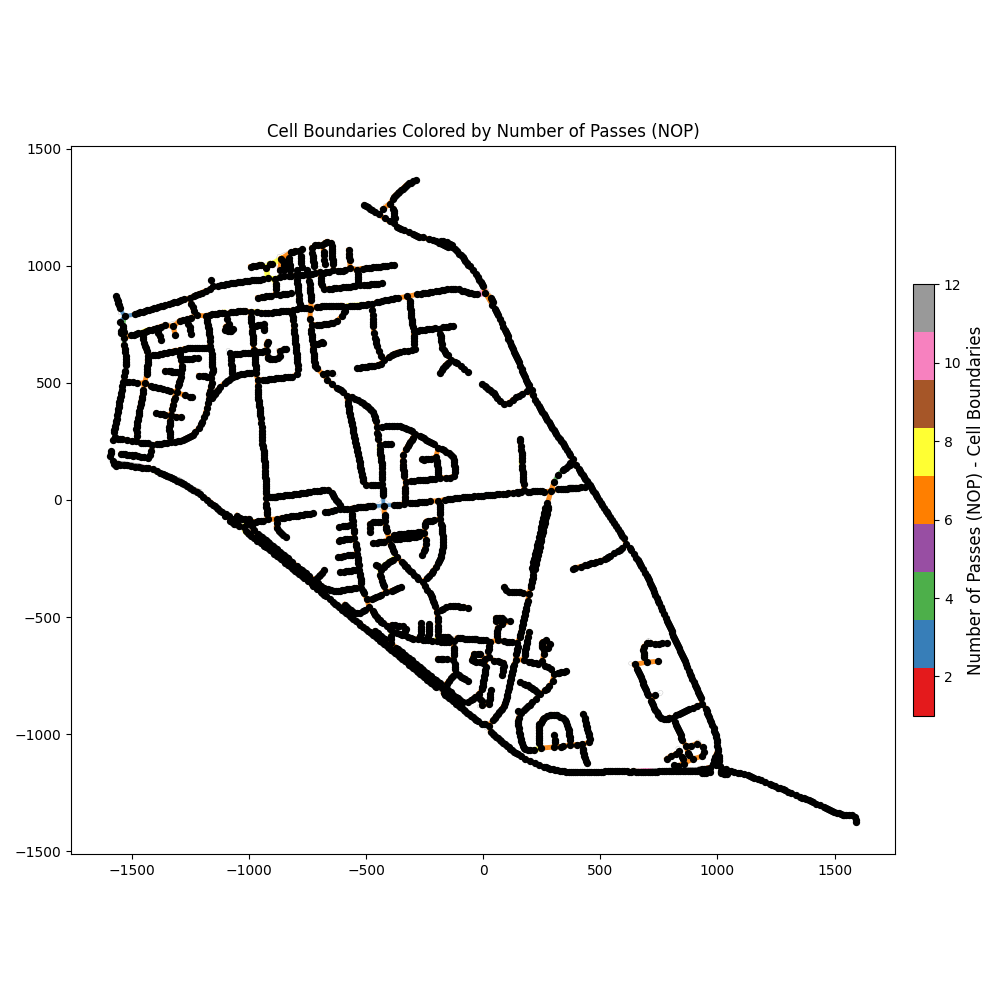

In [26]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the cells for reference/background (optional)
if 'geometry' in cell_gdf.columns:
    cell_gdf.plot(ax=ax, facecolor='none', edgecolor='gray', linewidth=0.3, alpha=0.5, zorder=0)

# Gather all 'distance' attributes to scale line thickness
edge_distances = [G[u][v].get('distance', 1) for u, v in G.edges()]
max_dist = max(edge_distances) if edge_distances else 1

# Gather all 'numberOfIntersection' to use for line colormap/width
all_nop = [G[u][v].get('numberOfIntersection', 0) for u, v in G.edges()]
max_nop = max(all_nop) if all_nop else 1

# Use a colormap to represent number of passes (nop)
norm = plt.Normalize(vmin=min(all_nop) if all_nop else 0, vmax=max_nop)
cmap = cm.Set1

# Draw cell boundaries, colored by the number of passes across the boundary if available
from shapely.geometry import LineString
import geopandas as gpd

boundary_lines = []
boundary_colors = []
boundary_widths = []

for u, v in G.edges():
    if 'centroid' in G.nodes[u] and 'centroid' in G.nodes[v]:
        p1 = G.nodes[u]['centroid']
        p2 = G.nodes[v]['centroid']
        line = LineString([p1, p2])
        nop = G[u][v].get('numberOfIntersection', 0)
        color = cmap(norm(nop))
        linewidth = 2 + 3 * (nop / max_nop) if max_nop > 0 else 2

        boundary_lines.append(line)
        boundary_colors.append(color)
        boundary_widths.append(linewidth)

        # (optional, legacy plot for reference -- not needed if using GeoPandas below)
        # ax.plot([p1.x, p2.x], [p1.y, p2.y], color=color, linewidth=linewidth, alpha=0.85)

# Make a GeoDataFrame for colored boundaries
boundary_gdf = gpd.GeoDataFrame({'geometry': boundary_lines, 
                                 'nop': [G[u][v].get('numberOfIntersection', 0) for u, v in G.edges()]})

# Plot the colored boundaries
for line, color, lw in zip(boundary_lines, boundary_colors, boundary_widths):
    x, y = line.xy
    ax.plot(x, y, color=color, linewidth=lw, alpha=0.85)

# Plot the nodes in black color
node_x = []
node_y = []
for node in G.nodes():
    centroid = G.nodes[node].get('centroid', None)
    if centroid is not None:
        node_x.append(centroid.x)
        node_y.append(centroid.y)
ax.scatter(node_x, node_y, color='black', s=18, zorder=5, label='Nodes')

#survey_gdf.plot(ax = ax, color = 'lightgray', zorder = 0)

# Create a colorbar for NOP on boundary lines
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Number of Passes (NOP) - Cell Boundaries', fontsize=12)

ax.set_aspect('equal')
ax.set_title('Cell Boundaries Colored by Number of Passes (NOP)')
plt.tight_layout()
plt.show()

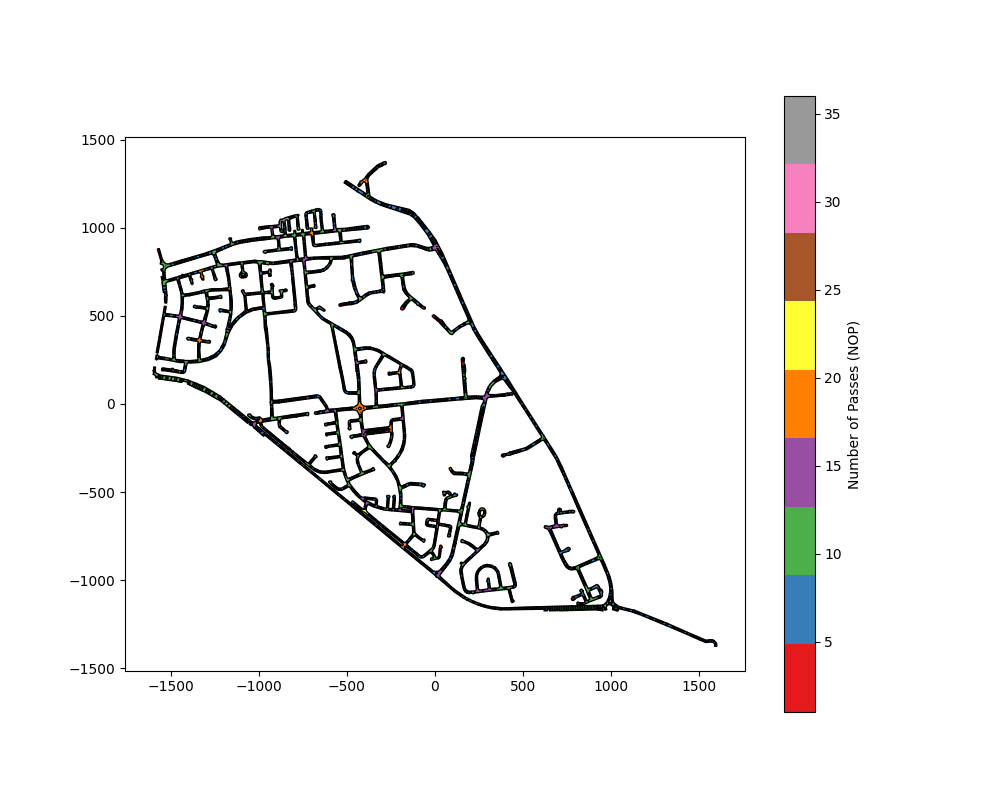

In [27]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(10, 8))

cax = cell_output.plot(
    ax=ax,
    column='nop',
    cmap='Set1',
    legend=True,
    legend_kwds={'label': "Number of Passes (NOP)"},
    edgecolor = 'black',
    zorder=0
)
#survey_gdf.plot(ax = ax, color = 'lightgray', zorder = 0)


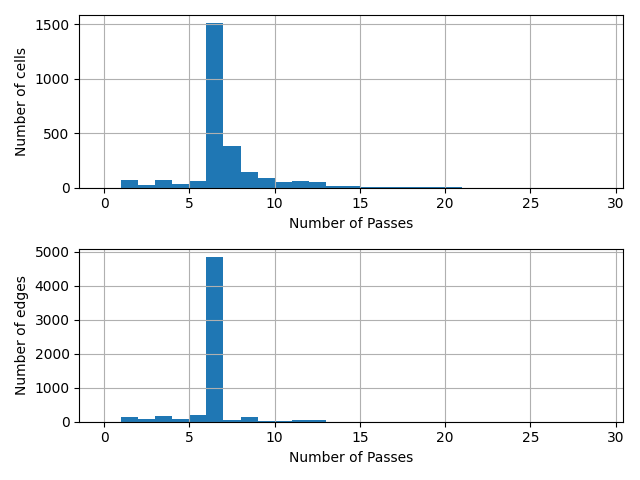

In [28]:
fig, ax = plt.subplots(2, 1)
bin_edges = np.arange(0, 30, 1)

# Top plot
nop_count['nop'].hist(bins=bin_edges, ax=ax[0])
ax[0].set_ylabel('Number of cells')
ax[0].set_xlabel('Number of Passes')

# Bottom plot
edges_wnop_gdf['nop'].hist(bins=bin_edges, ax=ax[1])
ax[1].set_ylabel('Number of edges')
ax[1].set_xlabel('Number of Passes')

plt.tight_layout()

In [29]:
# Estimate the size/weight of cell_gdf if stored in PostgreSQL using GeoPandas' to_postgis utility
# and an approximate calculation of the storage size

# 1. First, get rough memory usage in Python as a lower bound
approx_size_mb = cell_gdf.memory_usage(deep=True).sum() / 1e6
print(f"Approximate dataframe size in-memory: {approx_size_mb:.1f} MB")

# 2. Estimate as a PostgreSQL/PostGIS table (geometry and column types matter!)
# Main factors: attribute data, geometry (usually WKB in PostGIS), indexing, storage overhead.
# Geometry storage size depends on complexity (number of vertices) and geometry type.

from shapely import wkb

# Estimate geometry storage size for ALL rows
geom_wkb_bytes_list = cell_gdf.geometry.apply(lambda geom: len(geom.wkb))
total_geom_bytes = geom_wkb_bytes_list.sum()
avg_geom_wkb_bytes = geom_wkb_bytes_list.mean()
print(f"Average geometry WKB length: {avg_geom_wkb_bytes:.1f} bytes")
print(f"Total geometry WKB bytes for all rows: {total_geom_bytes} bytes")

approx_geom_total = total_geom_bytes / 1e6  # MB

# Attribute (non-geometry) columns
attribute_cols = cell_gdf.drop(columns="geometry")
attributes_size = attribute_cols.memory_usage(deep=True).sum() / 1e6

# Total estimate for PostgreSQL/PostGIS (excluding index, overhead):
postgres_estimate_mb = attributes_size + approx_geom_total
print(f"Estimated minimum PostgreSQL/PostGIS storage (excluding indexing/overhead): {postgres_estimate_mb:.1f} MB")

# For production or more precise estimation, upload using .to_postgis() and check table size using pg_total_relation_size.

Approximate dataframe size in-memory: 0.0 MB
Average geometry WKB length: 169.4 bytes
Total geometry WKB bytes for all rows: 442593 bytes
Estimated minimum PostgreSQL/PostGIS storage (excluding indexing/overhead): 0.4 MB
